In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

seaborn.set()

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],
    "font.size" : 10,
    "figure.dpi" : 300
})

split_order = ['Treino', 'Validação', 'Teste']
split_palette = {'Treino':'b', 'Validação':'g', 'Teste':'r'}


# Default is silver ratio
def get_figsize(fig_ratio=1/2.414, text_width_ratio=1, orientation='landscape'):
    text_width = 210 - 30 - 20 # A4 - bordas
    width_inch = (text_width * text_width_ratio) / 25.4
    if orientation == 'landscape':
        height_inch = width_inch * fig_ratio
    elif orientation == 'portrait':
        height_inch = width_inch * fig_ratio
    else:
        raise ValueError("orientation must be 'landscape' or 'portrait'") 
        
    return width_inch, height_inch


def make_split_handles(alpha=1.0, marker='r'):
    #return [Line2D([],[], linewidth=0, marker=marker, #markeredgewidth=0, markersize=10,
    #                  color=split_palette[s], alpha=alpha, label=s) for s in split_order]
    return [Patch(facecolor=split_palette[s], alpha=alpha, label=s) for s in split_order]


%matplotlib notebook

In [2]:
# Importa todos os dados

sizes = np.loadtxt('./dados/migrated_survey_sizes.txt')
sizes.sort()


survey_info = pd.read_csv('./dados/survey_info.csv', sep='\t')
survey_info.dx.replace('None', pd.NA, inplace=True)
survey_info['dx'] = pd.to_numeric(survey_info['dx'])
survey_info.drop(columns=['eastLong', 'northLat', 'southLat', 'westLong']).describe()


header_info = pd.read_csv('./dados/header_info.csv', sep='\t')
# Add split info and truncate num traces
header_info = header_info.merge(survey_info[['survey', 'split']], how='left', left_on='SURVEY', right_on='survey')
header_info.loc[header_info['NUM TRACES'] > 7000, 'NUM TRACES'] = 8000

## Tamanho dos surveys migrados

---

In [ ]:
save_file = './figuras/survey_sizes.pdf'
save_plot = True

vline_color = 'k'
hline_color = 'k'

figsize = get_figsize()

plt.figure(figsize=figsize, dpi=300)
plt.bar(np.arange(1,sizes.size+1),sizes, color='g', width=1.0, align='edge', edgecolor='green')

cum = np.cumsum(sizes)
half_index = len(cum[cum < sizes.sum()/2])
plt.axvline(half_index, color=vline_color, linestyle='--')
#plt.text(half_index-6,sizes.max()/2,'50 \% vol. total',rotation=90, color=vline_color)
plt.text(half_index-6, 3000,'50% vol. total',rotation=90, color=vline_color)

plt.axhline(300, color=hline_color, linestyle='--')
plt.text(3,500,'limiar (300 MB)',color=hline_color)

plt.xlabel('Prospecção')
plt.ylabel('Tamanho (MB)')
plt.xticks(list(range(0,sizes.size,20)))

plt.tight_layout()

if save_plot:
    plt.savefig(save_file)
else:
    plt.show()

## Estatísticas sobre conjunto limpo de survey

---

<IPython.core.display.Javascript object>


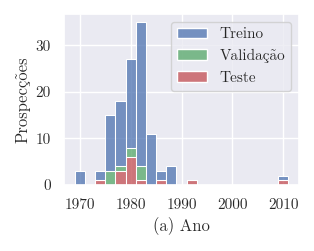

In [6]:
# Surveys por ano
save_file = './figuras/surveys_by_year.pdf'
save_plot = True
xlabel = '(a) Ano'

# Opções: 'layer', 'dodge', 'stack', 'fill'
multiple = 'stack'

figsize = get_figsize(fig_ratio=0.8, text_width_ratio=0.5)
plt.figure(figsize=figsize)
ax = seaborn.histplot(x='year', legend=True, 
                 hue='split', hue_order=split_order, palette=split_palette,
                 multiple=multiple, data=survey_info)
ax.set_xlabel(xlabel)
ax.set_ylabel('Prospecções')
ax.legend_.set_title('')

plt.tight_layout()
if save_plot:
    plt.savefig(save_file)
else:
    plt.show()

In [40]:
survey_info.query("`year` > 1974 and `year` < 1986").groupby('year')['survey'].count().sum()/122

0.8934426229508197

In [60]:
survey_info.groupby('dx')['survey'].count()
print((21 + 33 + 18 + 12)/122)

0.6885245901639344


<IPython.core.display.Javascript object>


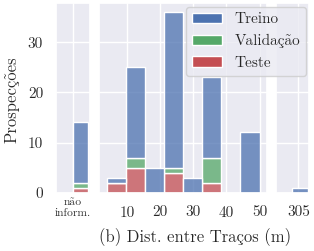

In [55]:
# dx
save_file = './figuras/surveys_by_dx.pdf'
save_plot = False
xlabel = '(b) Dist. entre Traços (m)'

multiple = 'stack'

figsize = get_figsize(fig_ratio=0.8, text_width_ratio=0.5)
fig, (ax0, ax1, ax2) = plt.subplots(nrows=1, ncols=3, sharey=True, constrained_layout=True,
                               figsize=figsize, gridspec_kw={'width_ratios': [1, 5, 1]})

# plot NaNs
not_informed = survey_info[np.isnan(survey_info['dx'])].copy()
not_informed['dx'] = not_informed['dx'].fillna(0)

seaborn.histplot(x='dx', ax=ax0, legend=False, bins=2,
                 hue='split', hue_order=split_order, palette=split_palette,
                 multiple=multiple, data=not_informed)

seaborn.histplot(x='dx', ax=ax1, legend=False, 
                 hue='split', hue_order=split_order, palette=split_palette,
                 multiple=multiple, data=survey_info[survey_info.dx < 300])

seaborn.histplot(x='dx', ax=ax2, legend=False, bins=2,
                 hue='split', hue_order=split_order, palette=split_palette,
                 multiple=multiple, data=survey_info[survey_info.dx >= 300])

ax0.set_xticks([0], labels=["não\ninform."], fontsize='smaller', position=(0,0.049))
#ax0.set_xlabel('*não informado', loc='left')
ax0.set_xlabel('')
ax0.set_ylabel('')
#ax0.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,y: "n.i.*"))
#ax0.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,y: "não\ninform."))

ax1.set_xticks([10*(i+1) for i in range(5)])
ax1.set_xlabel('')
ax1.set_ylabel('')

ax2.set_xticks([305])
ax2.set_xlabel('')

handles = make_split_handles()
fig.legend(handles=handles)

fig.supxlabel(xlabel, x=0.62)
fig.supylabel('Prospecções', y=0.6)

#plt.tight_layout()
if save_plot:
    plt.savefig(save_file)
else:
    plt.show()
    

In [24]:
#print(survey_info['dx'].describe(percentiles=[0.15,0.50,0.85]))
len(survey_info.query('dx >= 12.5 and dx <= 50'))/len(survey_info)

0.8524590163934426

## Estatísticas sobre conjunto limpo de survey

---

In [ ]:
yscale = 'log'
yscale = 'linear'

h = seaborn.histplot(x='TRACE NS', data=header_info, binwidth=200)
h.set_yscale(yscale)

<IPython.core.display.Javascript object>


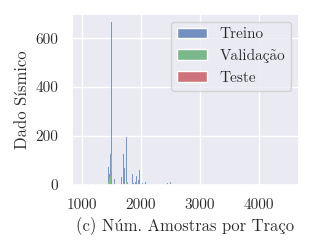

In [18]:
# Núm. amostras por traço
save_file = './figuras/num_samples_per_trace.pdf'
save_plot = False
xlabel = '(c) Núm. Amostras por Traço'

# Opções: 'layer', 'dodge', 'stack', 'fill'
multiple = 'stack'

figsize = get_figsize(fig_ratio=0.8, text_width_ratio=0.5)
plt.figure(figsize=figsize)
ax = seaborn.histplot(x='TRACE NS', legend=True, binwidth=10,
                 hue='split', hue_order=split_order, palette=split_palette,
                 multiple=multiple, data=header_info)
ax.set_xlabel(xlabel)
ax.set_ylabel('Dado Sísmico')
ax.legend_.set_title('')

plt.tight_layout()
if save_plot:
    plt.savefig(save_file)
else:
    plt.show()

In [17]:
binwidth = 1000
trace_ns = header_info['TRACE NS']
bins = range(0,trace_ns.max()+1,binwidth)
count, _ = np.histogram(trace_ns, bins)

total = count.sum()
for b, c in zip(bins, count.cumsum()):
    print("{} - {:.1f}%".format(b, c/total*100))

[   0 2292  286    9]
0 - 0.0%
1000 - 88.6%
2000 - 99.7%
3000 - 100.0%


<IPython.core.display.Javascript object>


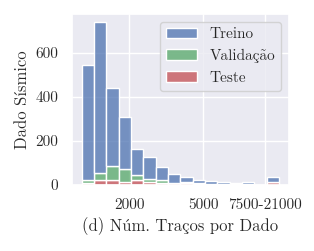

In [25]:
# Núm. traços por dado
save_file = './figuras/num_traces_per_data.pdf'
save_plot = False
xlabel = '(d) Núm. Traços por Dado'

# Opções: 'layer', 'dodge', 'stack', 'fill'
multiple = 'stack'


figsize = get_figsize(fig_ratio=0.8, text_width_ratio=0.5)
plt.figure(figsize=figsize)
ax = seaborn.histplot(x='NUM TRACES', legend=True, binwidth=500,
                 hue='split', hue_order=split_order, palette=split_palette,
                 multiple=multiple, data=header_info)
ax.set_xlabel(xlabel)
ax.set_ylabel('Dado Sísmico')
ax.legend_.set_title('')
ax.set_xticks([2000, 5000, 7500])

def format_func(value, tick_number):
    value = int(value)
    #value = value/1000
    #scale = 1
    if value <= 7000:
        return str(value)
    else:
        #return r"${0}\pi$".format(N // 2)
        return "{}-21000".format(value)
ax.xaxis.set_major_formatter(plt.FuncFormatter(format_func))

plt.tight_layout()
if save_plot:
    plt.savefig(save_file)
else:
    plt.show()

In [24]:
binwidth = 500
num_traces = header_info['NUM TRACES']
bins = range(0,num_traces.max()+1,binwidth)
bins = [0,500,2500,7500]
count, _ = np.histogram(num_traces, bins)

total = count.sum()
for b, c in zip(bins, count):
    print("{} - {:.1f}%".format(b, c/total*100))

0 - 16.9%
500 - 68.2%
2500 - 14.9%


## Informações textuais

---

In [11]:
header_info.columns

Index(['SURVEY', 'FILE', 'DATA FORMAT', 'SORTING CODE', 'MEASUREMENT SYSTEM',
       'SEGY REVISION', 'FIXED LENGTH TRACE', 'NUM TRACES',
       'TRACE IDENTIFICATION', 'TRACE NS', 'TRACE DT', 'survey', 'split'],
      dtype='object')

In [10]:
print("Total de instâncias:", header_info['FILE'].count())
print("Total de prospecções:", header_info['SURVEY'].unique().size)

Total de instâncias: 2588
Total de prospecções: 122


count    2588.000000
mean        9.938753
std         9.634094
min         0.330400
10%         2.467211
50%         7.053028
80%        14.015843
max       128.000000
dtype: float64


<IPython.core.display.Javascript object>


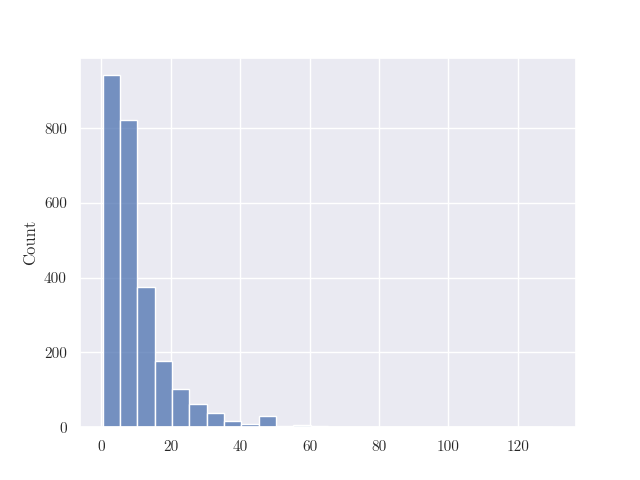

<AxesSubplot:ylabel='Count'>

In [23]:
percentiles = [i/100 for i in range(10,100,10)]
percentiles = [0.1, 0.8]
image_size = (header_info['NUM TRACES'] * header_info['TRACE NS'] * 4) / 10**6
print(image_size.describe(percentiles=percentiles))

seaborn.histplot(image_size, binwidth=5)


In [ ]:
# Colocar textual

# Técnica de migração
s = survey_info.groupby('migration_technique')['migration_technique'].count()
print(s)

In [ ]:
col = 'DATA FORMAT'

group = header_info.groupby(col)[col].count()
group.rename(index={1:'IBM', 5:'IEEE'}, inplace=True)
print(group)
#plt.figure()
#group.plot.pie()

In [ ]:
col = 'SEGY REVISION'
group = header_info.groupby(col)[col].count()
group.rename(index={0:'Rev 0', 256:'Rev 1'}, inplace=True)
print(group)

In [26]:
group = survey_info.groupby('split')#, as_index=False)
for s, a in group.agg({'area' : 'unique'}).iterrows():
    areas = sorted(a['area'])
    print(s, end=': ')
    print(*areas, sep=', ', end='.\n')
    
print("Núm. de áreas:", len(survey_info['area'].unique()))

Teste: Bacia Argentina, Mar de Bering, Washington - Oregon.
Treino: Golfo do Alasca, Oceano Atlântico Norte, Oceano Ártico, Sul da Califórnia.
Validação: Mar do Caribe, Norte da Califórnia.
Núm. de áreas: 9


In [24]:
# Tamanho de cada separação
split_size = survey_info.groupby('split')['clean_size'].sum()

total = split_size.sum()/1000

for s in split_order:
    size = split_size[s]/1000
    print("{}\t{:.1f} GB\t{:.1f}%".format(s, size, size/total*100))
print()
print("{}\t{:.1f} GB".format('Total', total))

Treino	19.6 GB	78.1%
Validação	2.7 GB	10.8%
Teste	2.8 GB	11.1%

Total	25.1 GB
